# Empirical Mode Decomposition (EMD)

> **Primary reference (this repo)**: Zeiler, A. et al. (2010). *Empirical Mode Decomposition — An Introduction*. IEEE.
>
> **Foundational paper**: Huang, N. E. et al. (1998). *The empirical mode decomposition and the Hilbert spectrum for nonlinear and non-stationary time series analysis*. Proc. R. Soc. Lond. A, 454, 903–995.

EMD is the first widely used **fully adaptive** signal-decomposition method: the basis functions (Intrinsic Mode Functions, IMFs) are derived from the data themselves, without a predefined Fourier or wavelet dictionary.

This notebook walks through the **complete sifting pipeline** with visualizations at every stage:

1. Motivation and IMF definition  
2. Algorithm overview (paper flow diagram)  
3. Demo signal  
4. Extremum detection  
5. Upper / lower envelope construction  
6. Local mean (low-frequency trend)  
7. One sifting step: subtract the mean  
8. Multiple sifting iterations until an IMF  
9. Full EMD with PySDKit  
10. Completeness and reconstruction  
11. Summary  


## 1. Motivation and IMF definition

### 1.1 Why EMD?

Biomedical and physical recordings are typically **nonlinear and non-stationary**. Classical Fourier analysis assumes globally constant amplitudes and frequencies; fixed wavelet frames still impose a predefined dictionary. EMD instead *empirically* identifies oscillatory modes by their local time scales.

### 1.2 Intrinsic Mode Functions (IMFs)

An IMF $x_n(t)$ must satisfy (Zeiler et al. / Huang et al.):

1. **Extremum–zero-crossing balance**: between two successive zero crossings there is only one extremum — equivalently, the numbers of local maxima and minima differ by at most one.  
2. **Zero local mean**: the mean of the upper and lower envelopes is (approximately) zero.

An IMF may still have **amplitude and frequency modulation**; the zero-mean condition makes subsequent Hilbert analysis physically meaningful.

### 1.3 Decomposition identity

$$
x(t)=\sum_{n} x_n(t)+r(t),
$$
where $x_n$ are IMFs and $r$ is a slowly varying residue (trend). Completeness is automatic: summing IMFs and residue recovers $x(t)$.


## 2. Algorithm overview (sifting)

Paper §II / Fig. 1. To extract the $n$-th IMF from the current residue $r_{n-1}(t)$:

0. Initialize $h_0(t):=r_{n-1}(t)$, $k:=1$.  
1. **Find extrema** of $h_{k-1}(t)$.  
2. **Interpolate** cubic-spline envelopes $U_{k-1}(t)$ (through maxima) and $L_{k-1}(t)$ (through minima).  
3. **Local mean** (low-frequency trend):
$$
m_{k-1}(t)=\frac{U_{k-1}(t)+L_{k-1}(t)}{2}.
$$
   (Some texts misprint this as a difference; the physically correct trend estimate is the **average** of the envelopes.)  
4. **Sift**:
$$
h_k(t)=h_{k-1}(t)-m_{k-1}(t).
$$
5. If $h_k$ is not yet an IMF, set $k\leftarrow k+1$ and repeat from step 1; otherwise set $x_n:=h_k$ and $r_n:=r_{n-1}-x_n$.  
6. Stop when $r_n$ is a monotonic / low-variation residuum; otherwise continue with $n\leftarrow n+1$.

The next cells implement and visualize steps 1–5 explicitly before calling the full PySDKit `EMD` class.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import sawtooth

from pysdkit import EMD
from pysdkit.data import test_emd
from pysdkit.plot import plot_IMFs

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float)
    est = np.asarray(est, dtype=float)
    return np.linalg.norm(est - ref) / (np.linalg.norm(ref) + 1e-16)


def find_extrema_simple(t, x):
    # Discrete extrema via first differences (same idea as EMD extrema_detection='simple').
    dx = np.diff(x)
    # maxima: + to -, minima: - to +
    max_idx = np.where((dx[:-1] > 0) & (dx[1:] <= 0))[0] + 1
    min_idx = np.where((dx[:-1] < 0) & (dx[1:] >= 0))[0] + 1
    # include endpoints if they behave like extrema for visualization
    if len(x) >= 2:
        if x[0] > x[1]:
            max_idx = np.unique(np.r_[0, max_idx])
        if x[0] < x[1]:
            min_idx = np.unique(np.r_[0, min_idx])
        if x[-1] > x[-2]:
            max_idx = np.unique(np.r_[max_idx, len(x) - 1])
        if x[-1] < x[-2]:
            min_idx = np.unique(np.r_[min_idx, len(x) - 1])
    return max_idx, min_idx


def cubic_envelope(t, t_ext, x_ext):
    # Build a cubic spline through extrema; require >= 2 points.
    if len(t_ext) < 2:
        return np.full_like(t, np.nan, dtype=float)
    # ensure strictly increasing abscissae
    order = np.argsort(t_ext)
    t_ext, x_ext = np.asarray(t_ext)[order], np.asarray(x_ext)[order]
    uniq = np.concatenate([[True], np.diff(t_ext) > 0])
    t_ext, x_ext = t_ext[uniq], x_ext[uniq]
    if len(t_ext) < 2:
        return np.full_like(t, np.nan, dtype=float)
    cs = CubicSpline(t_ext, x_ext, bc_type="not-a-knot", extrapolate=True)
    return cs(t)


def one_sift_step(t, h):
    # One complete sifting iteration: extrema -> envelopes -> mean -> h - m.
    max_idx, min_idx = find_extrema_simple(t, h)
    U = cubic_envelope(t, t[max_idx], h[max_idx])
    L = cubic_envelope(t, t[min_idx], h[min_idx])
    m = 0.5 * (U + L)
    h_new = h - m
    return {
        "max_idx": max_idx,
        "min_idx": min_idx,
        "U": U,
        "L": L,
        "m": m,
        "h_new": h_new,
    }

## 3. Demo signal

Following the spirit of paper Fig. 2 (sawtooth + sinusoid + linear trend), we build a transparent toy signal so every sifting stage is easy to interpret.


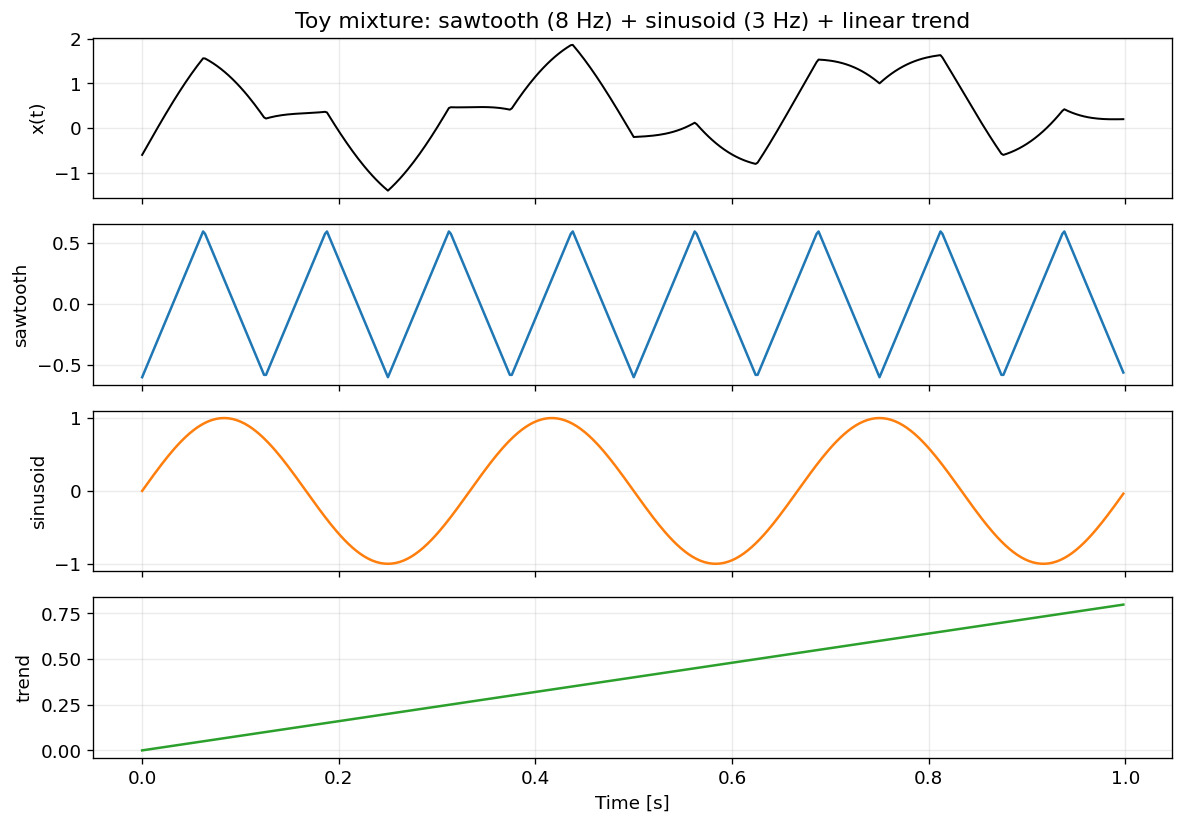

In [ ]:
fs = 500.0
duration = 1.0
t = np.arange(0, duration, 1.0 / fs)

# Components inspired by Zeiler et al., Fig. 2
comp_saw = 0.6 * sawtooth(2 * np.pi * 8 * t, width=0.5)
comp_sin = 1.0 * np.sin(2 * np.pi * 3 * t)
comp_trend = 0.8 * t
x = comp_saw + comp_sin + comp_trend

fig, axs = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
axs[0].plot(t, x, "k", lw=1.2)
axs[0].set_ylabel("x(t)")
axs[0].set_title("Toy mixture: sawtooth (8 Hz) + sinusoid (3 Hz) + linear trend")
axs[1].plot(t, comp_saw, color="C0")
axs[1].set_ylabel("sawtooth")
axs[2].plot(t, comp_sin, color="C1")
axs[2].set_ylabel("sinusoid")
axs[3].plot(t, comp_trend, color="C2")
axs[3].set_ylabel("trend")
axs[3].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## 4. Step A — Locate extrema

Sifting starts by identifying **all local maxima and minima** of the current prototype $h(t)$ (initially $h=x$).


Number of maxima: 10, minima: 10


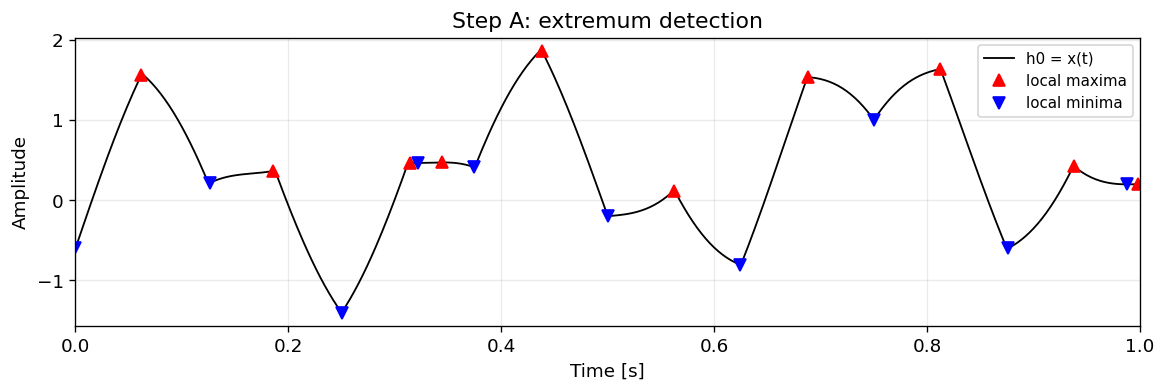

In [3]:
h0 = x.copy()
max_idx, min_idx = find_extrema_simple(t, h0)
print(f"Number of maxima: {len(max_idx)}, minima: {len(min_idx)}")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(t, h0, "k", lw=1.1, label="h0 = x(t)")
ax.plot(t[max_idx], h0[max_idx], "r^", ms=7, label="local maxima")
ax.plot(t[min_idx], h0[min_idx], "bv", ms=7, label="local minima")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Step A: extremum detection")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 5. Step B — Construct upper and lower envelopes

Cubic splines through the maxima give $U(t)$; through the minima give $L(t)$. These envelopes estimate the local oscillation range (paper Step 1c).


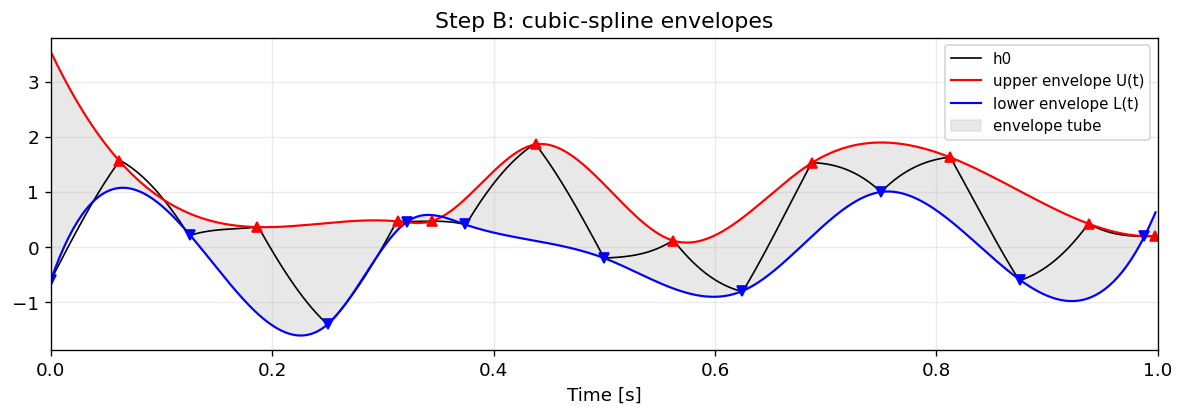

In [4]:
U0 = cubic_envelope(t, t[max_idx], h0[max_idx])
L0 = cubic_envelope(t, t[min_idx], h0[min_idx])

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, h0, "k", lw=1.0, label="h0")
ax.plot(t, U0, "r-", lw=1.3, label="upper envelope U(t)")
ax.plot(t, L0, "b-", lw=1.3, label="lower envelope L(t)")
ax.plot(t[max_idx], h0[max_idx], "r^", ms=6)
ax.plot(t[min_idx], h0[min_idx], "bv", ms=6)
ax.fill_between(t, L0, U0, color="0.85", alpha=0.6, label="envelope tube")
ax.set_xlabel("Time [s]")
ax.set_title("Step B: cubic-spline envelopes")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 6. Step C — Local mean (low-frequency trend)

$$
m(t)=\frac{U(t)+L(t)}{2}
$$
is the running estimate of the **slow local trend**. Removing it isolates the fast oscillation (the candidate IMF detail).


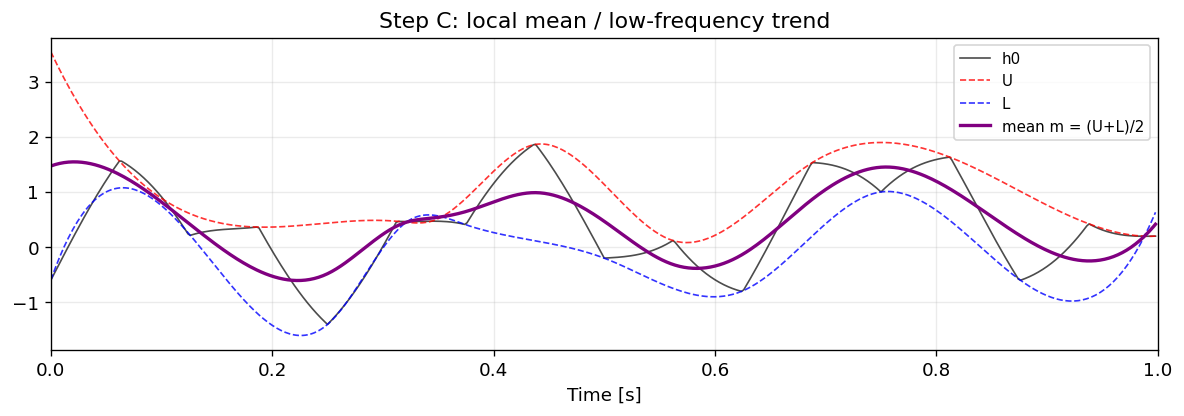

In [5]:
m0 = 0.5 * (U0 + L0)

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, h0, "k", lw=1.0, alpha=0.7, label="h0")
ax.plot(t, U0, "r--", lw=1.0, alpha=0.8, label="U")
ax.plot(t, L0, "b--", lw=1.0, alpha=0.8, label="L")
ax.plot(t, m0, color="purple", lw=2.0, label="mean m = (U+L)/2")
ax.set_xlabel("Time [s]")
ax.set_title("Step C: local mean / low-frequency trend")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 7. Step D — Subtract the mean (one sifting iteration)

$$
h_1(t)=h_0(t)-m_0(t).
$$
If $h_1$ already meets the IMF criteria, it becomes IMF$_1$; otherwise the same procedure is repeated on $h_1$.


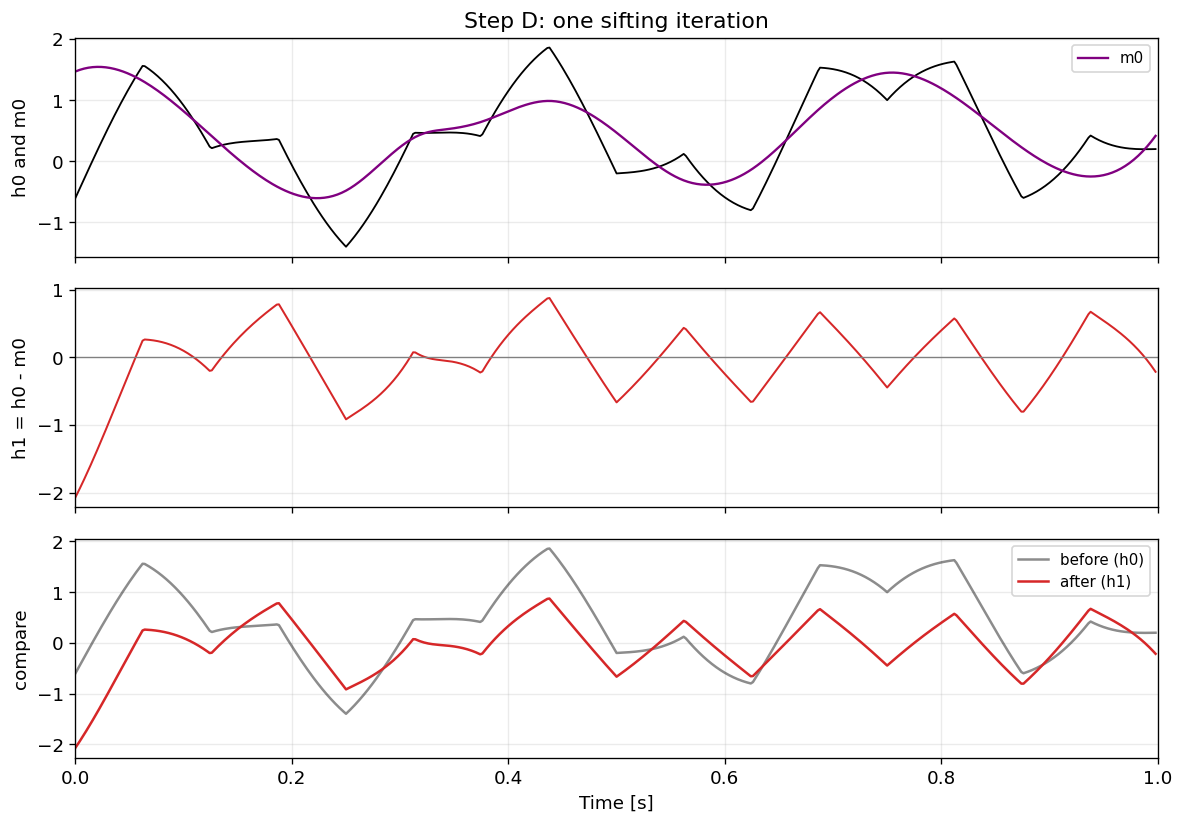

mean(h0) = 0.3991616000000001  | mean(h1) = -0.04273044876340019
The sifting step drives the prototype toward a zero-mean oscillation.


In [6]:
h1 = h0 - m0

fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axs[0].plot(t, h0, "k", lw=1.1)
axs[0].plot(t, m0, color="purple", lw=1.4, label="m0")
axs[0].legend(fontsize=9)
axs[0].set_ylabel("h0 and m0")
axs[0].set_title("Step D: one sifting iteration")
axs[1].plot(t, h1, color="C3", lw=1.2)
axs[1].axhline(0, color="0.5", lw=0.8)
axs[1].set_ylabel("h1 = h0 - m0")
axs[2].plot(t, h0, "k", alpha=0.45, label="before (h0)")
axs[2].plot(t, h1, color="C3", label="after (h1)")
axs[2].legend(fontsize=9)
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("compare")
axs[2].set_xlim(0, 1)
plt.tight_layout()
plt.show()

print("mean(h0) =", h0.mean(), " | mean(h1) =", h1.mean())
print("The sifting step drives the prototype toward a zero-mean oscillation.")

## 8. Multiple sifting iterations until an IMF-like mode

We repeat Steps A–D for several iterations and watch:

- envelopes become more symmetric;  
- the local mean shrinks toward zero;  
- the prototype becomes a zero-mean oscillation (IMF candidate).


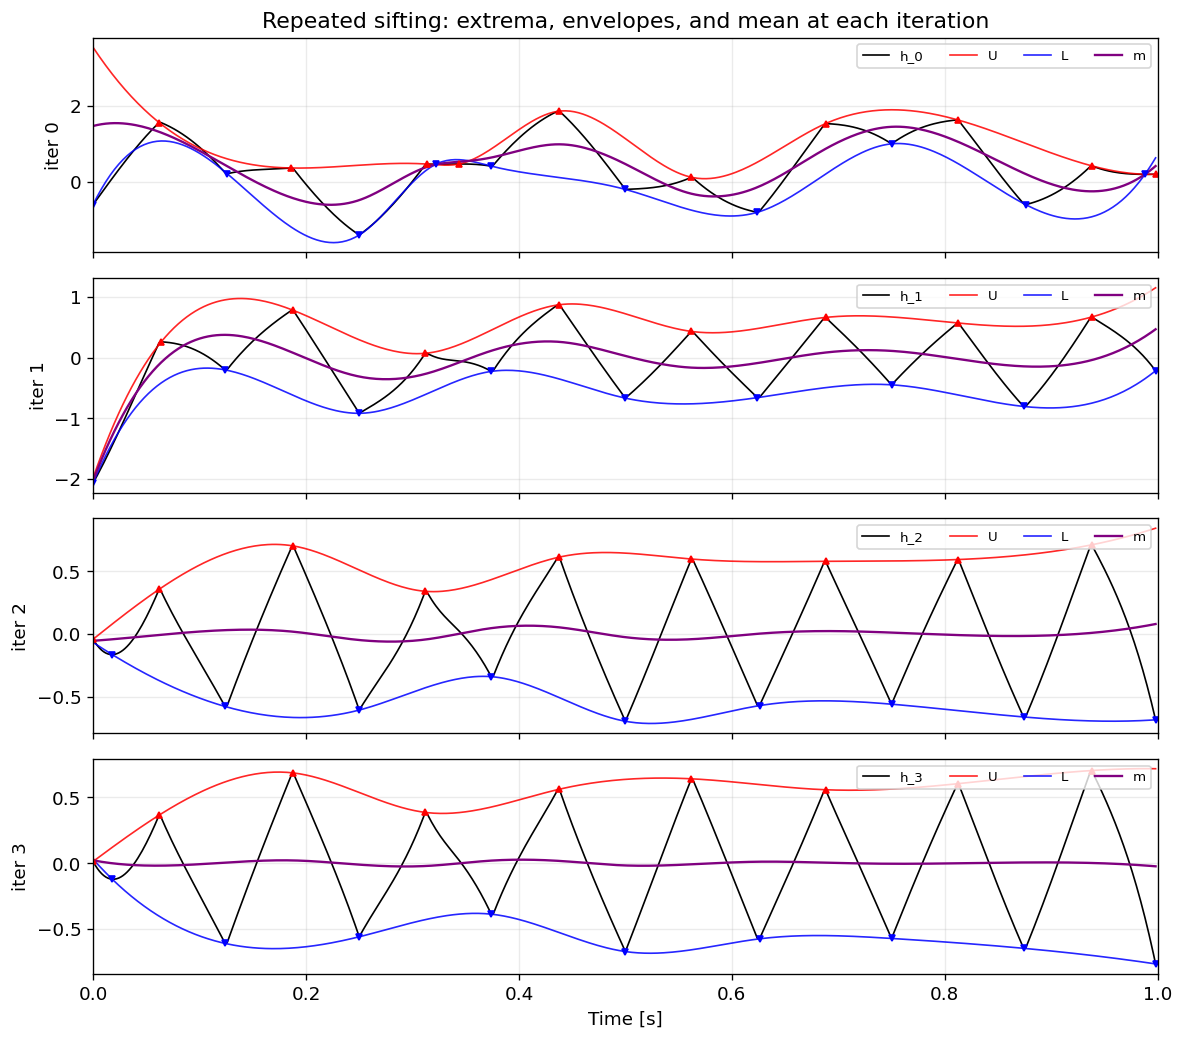

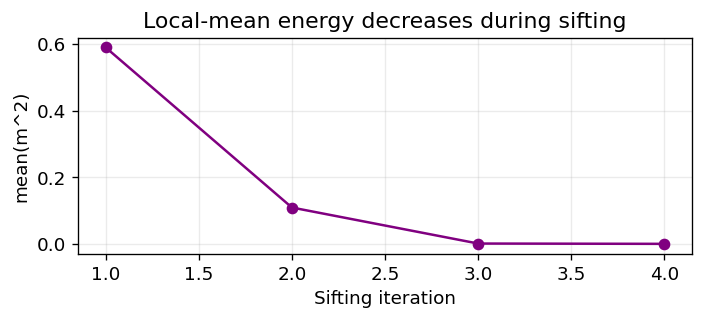

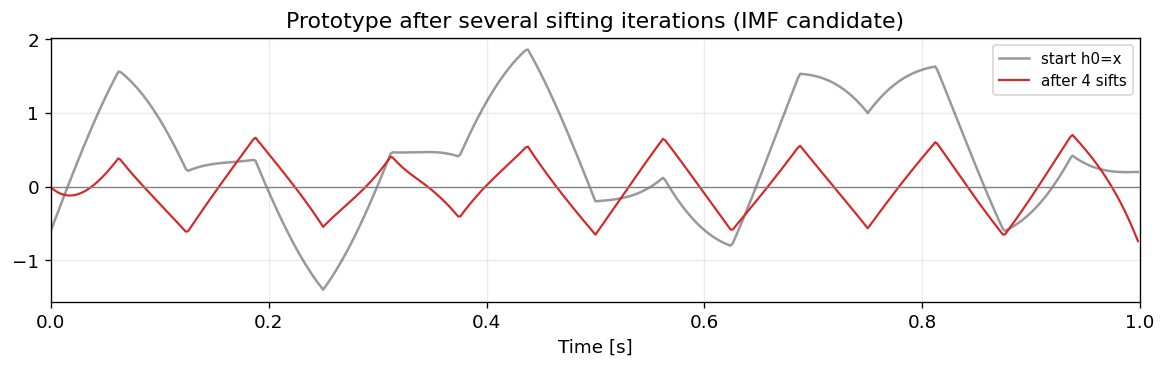

In [7]:
n_show = 4
h = x.copy()
history = [h.copy()]
means = []

fig, axs = plt.subplots(n_show, 1, figsize=(10, 2.2 * n_show), sharex=True)
for k in range(n_show):
    step = one_sift_step(t, h)
    means.append(step["m"])
    axs[k].plot(t, h, "k", lw=1.0, label=f"h_{k}")
    axs[k].plot(t, step["U"], "r-", lw=1.0, alpha=0.85, label="U")
    axs[k].plot(t, step["L"], "b-", lw=1.0, alpha=0.85, label="L")
    axs[k].plot(t, step["m"], color="purple", lw=1.4, label="m")
    axs[k].plot(t[step["max_idx"]], h[step["max_idx"]], "r^", ms=4)
    axs[k].plot(t[step["min_idx"]], h[step["min_idx"]], "bv", ms=4)
    axs[k].set_ylabel(f"iter {k}")
    axs[k].legend(loc="upper right", fontsize=8, ncol=4)
    h = step["h_new"]
    history.append(h.copy())
axs[-1].set_xlabel("Time [s]")
axs[0].set_title("Repeated sifting: extrema, envelopes, and mean at each iteration")
axs[-1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

# Mean-envelope energy shrinks with sifting
mean_energy = [np.mean(m**2) for m in means]
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(np.arange(1, len(mean_energy) + 1), mean_energy, "o-", color="purple")
ax.set_xlabel("Sifting iteration")
ax.set_ylabel("mean(m^2)")
ax.set_title("Local-mean energy decreases during sifting")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(t, history[0], "k", alpha=0.4, label="start h0=x")
ax.plot(t, history[-1], color="C3", lw=1.3, label=f"after {n_show} sifts")
ax.axhline(0, color="0.5", lw=0.8)
ax.legend(fontsize=9)
ax.set_xlabel("Time [s]")
ax.set_title("Prototype after several sifting iterations (IMF candidate)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 9. Full EMD with PySDKit

The educational cubic-spline demo above illustrates one residue’s sifting. Production EMD also handles boundary mirroring, stopping criteria, and successive IMF extraction. PySDKit’s `EMD` class implements that complete pipeline (PyEMD-style).


IMFs shape (n_imfs, T): (2, 500)
residue energy fraction: 0.2686555161792684


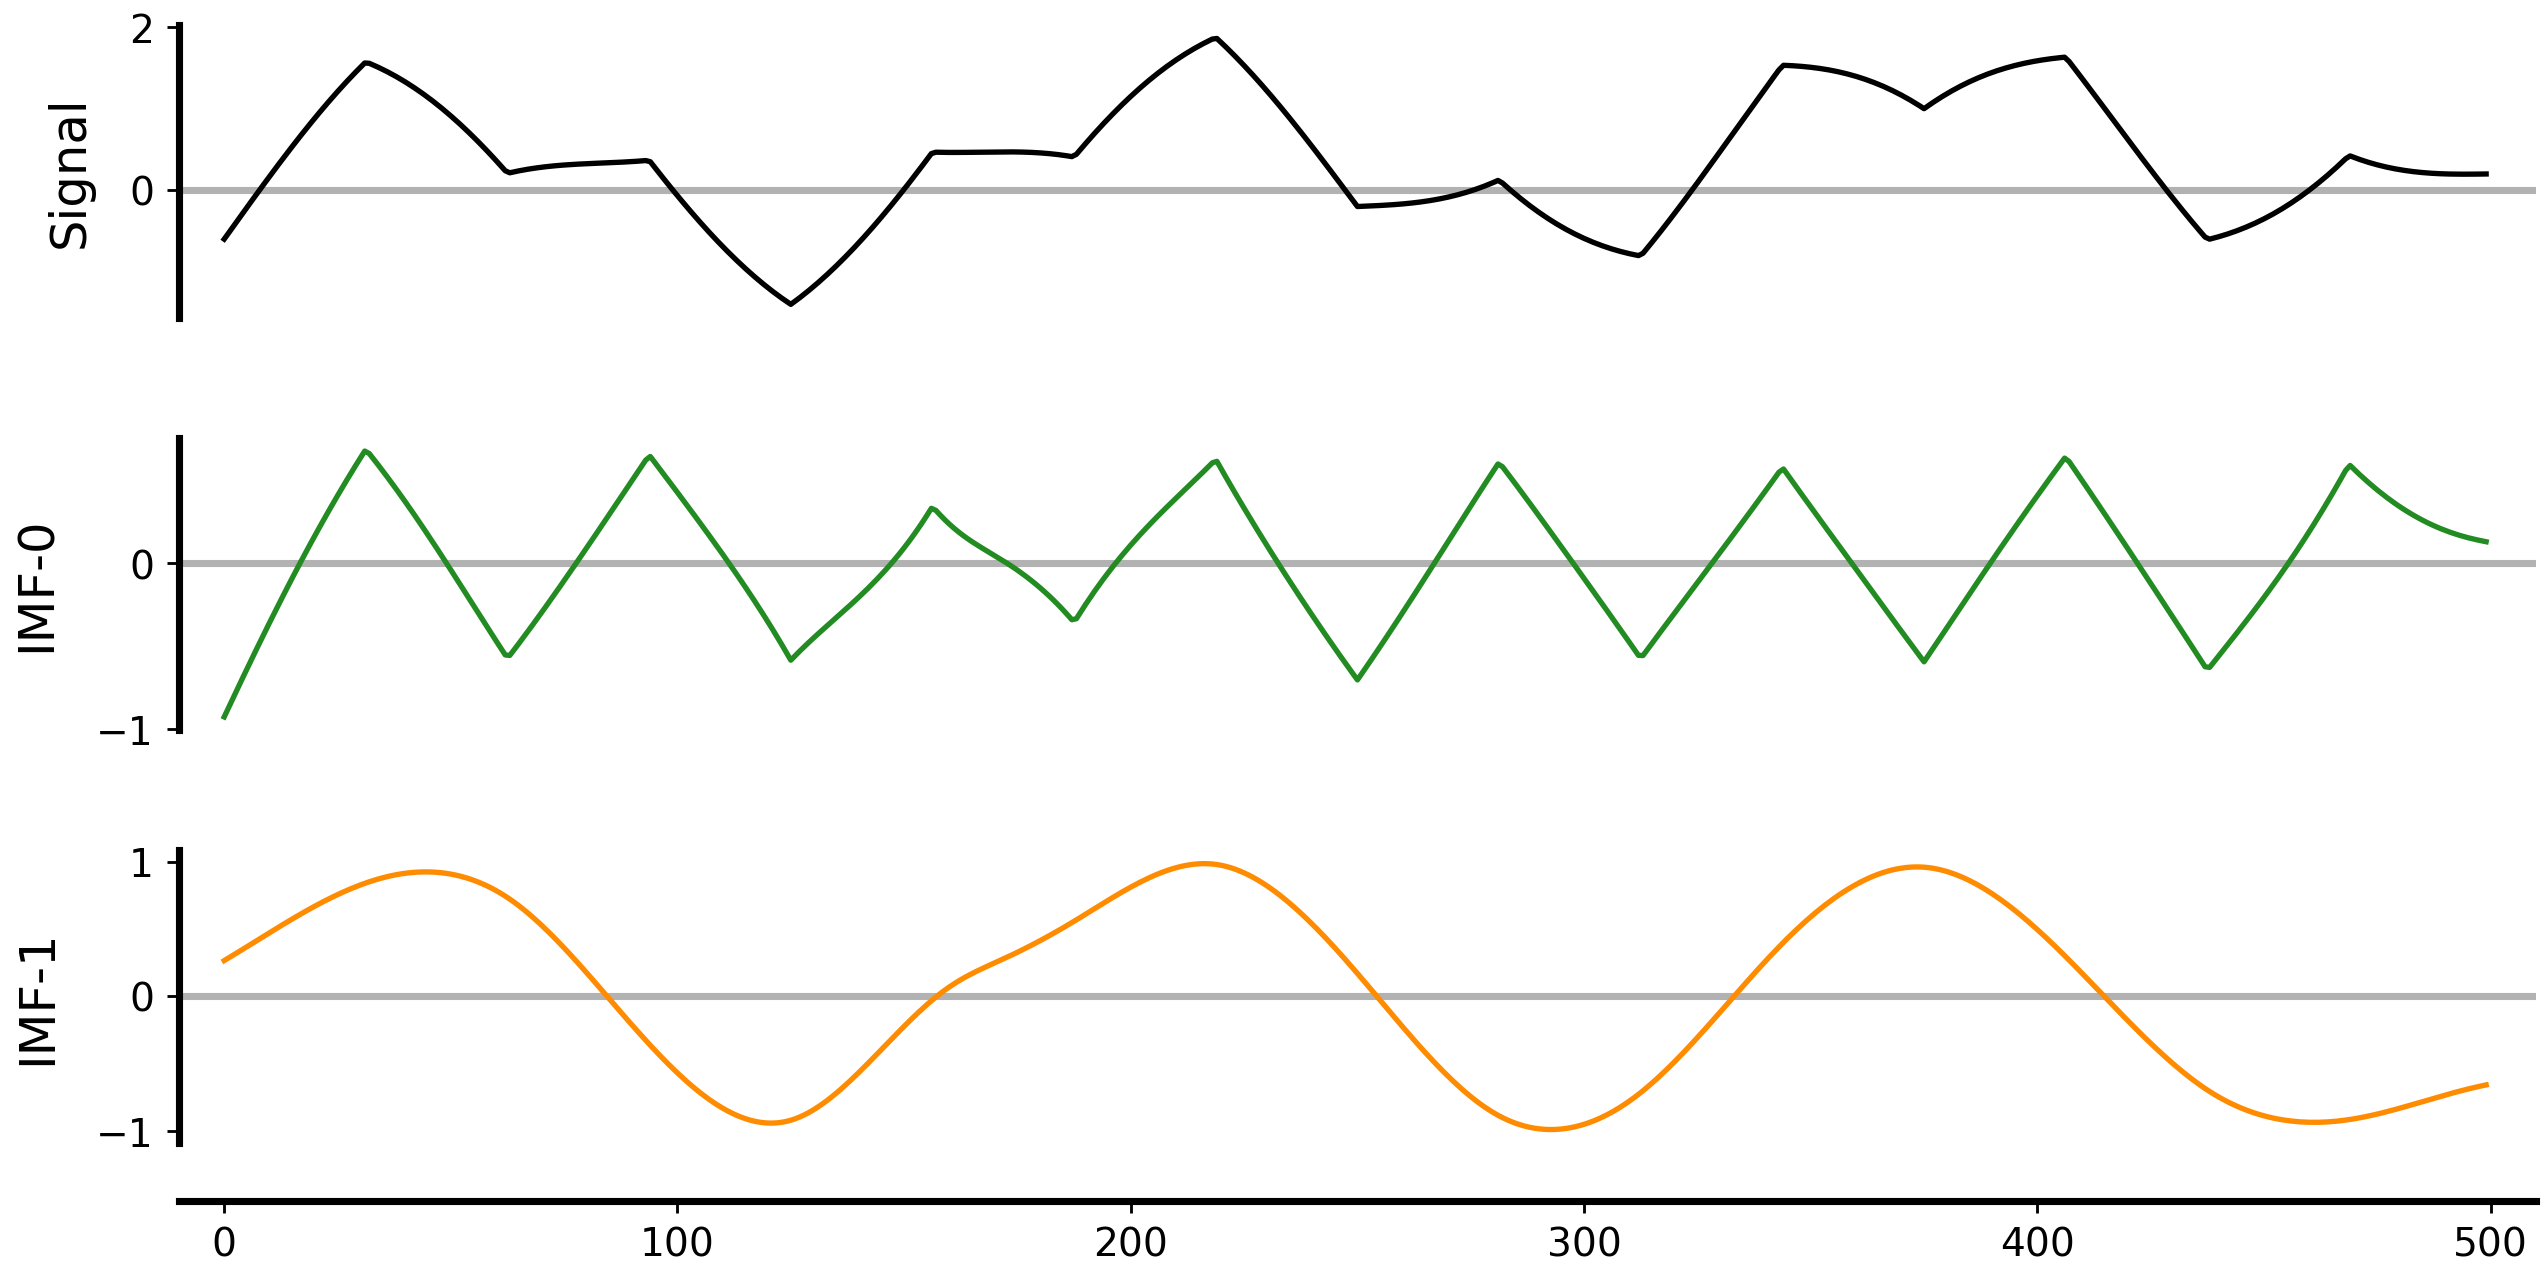

relative reconstruction error: 1.2001658127260488e-17


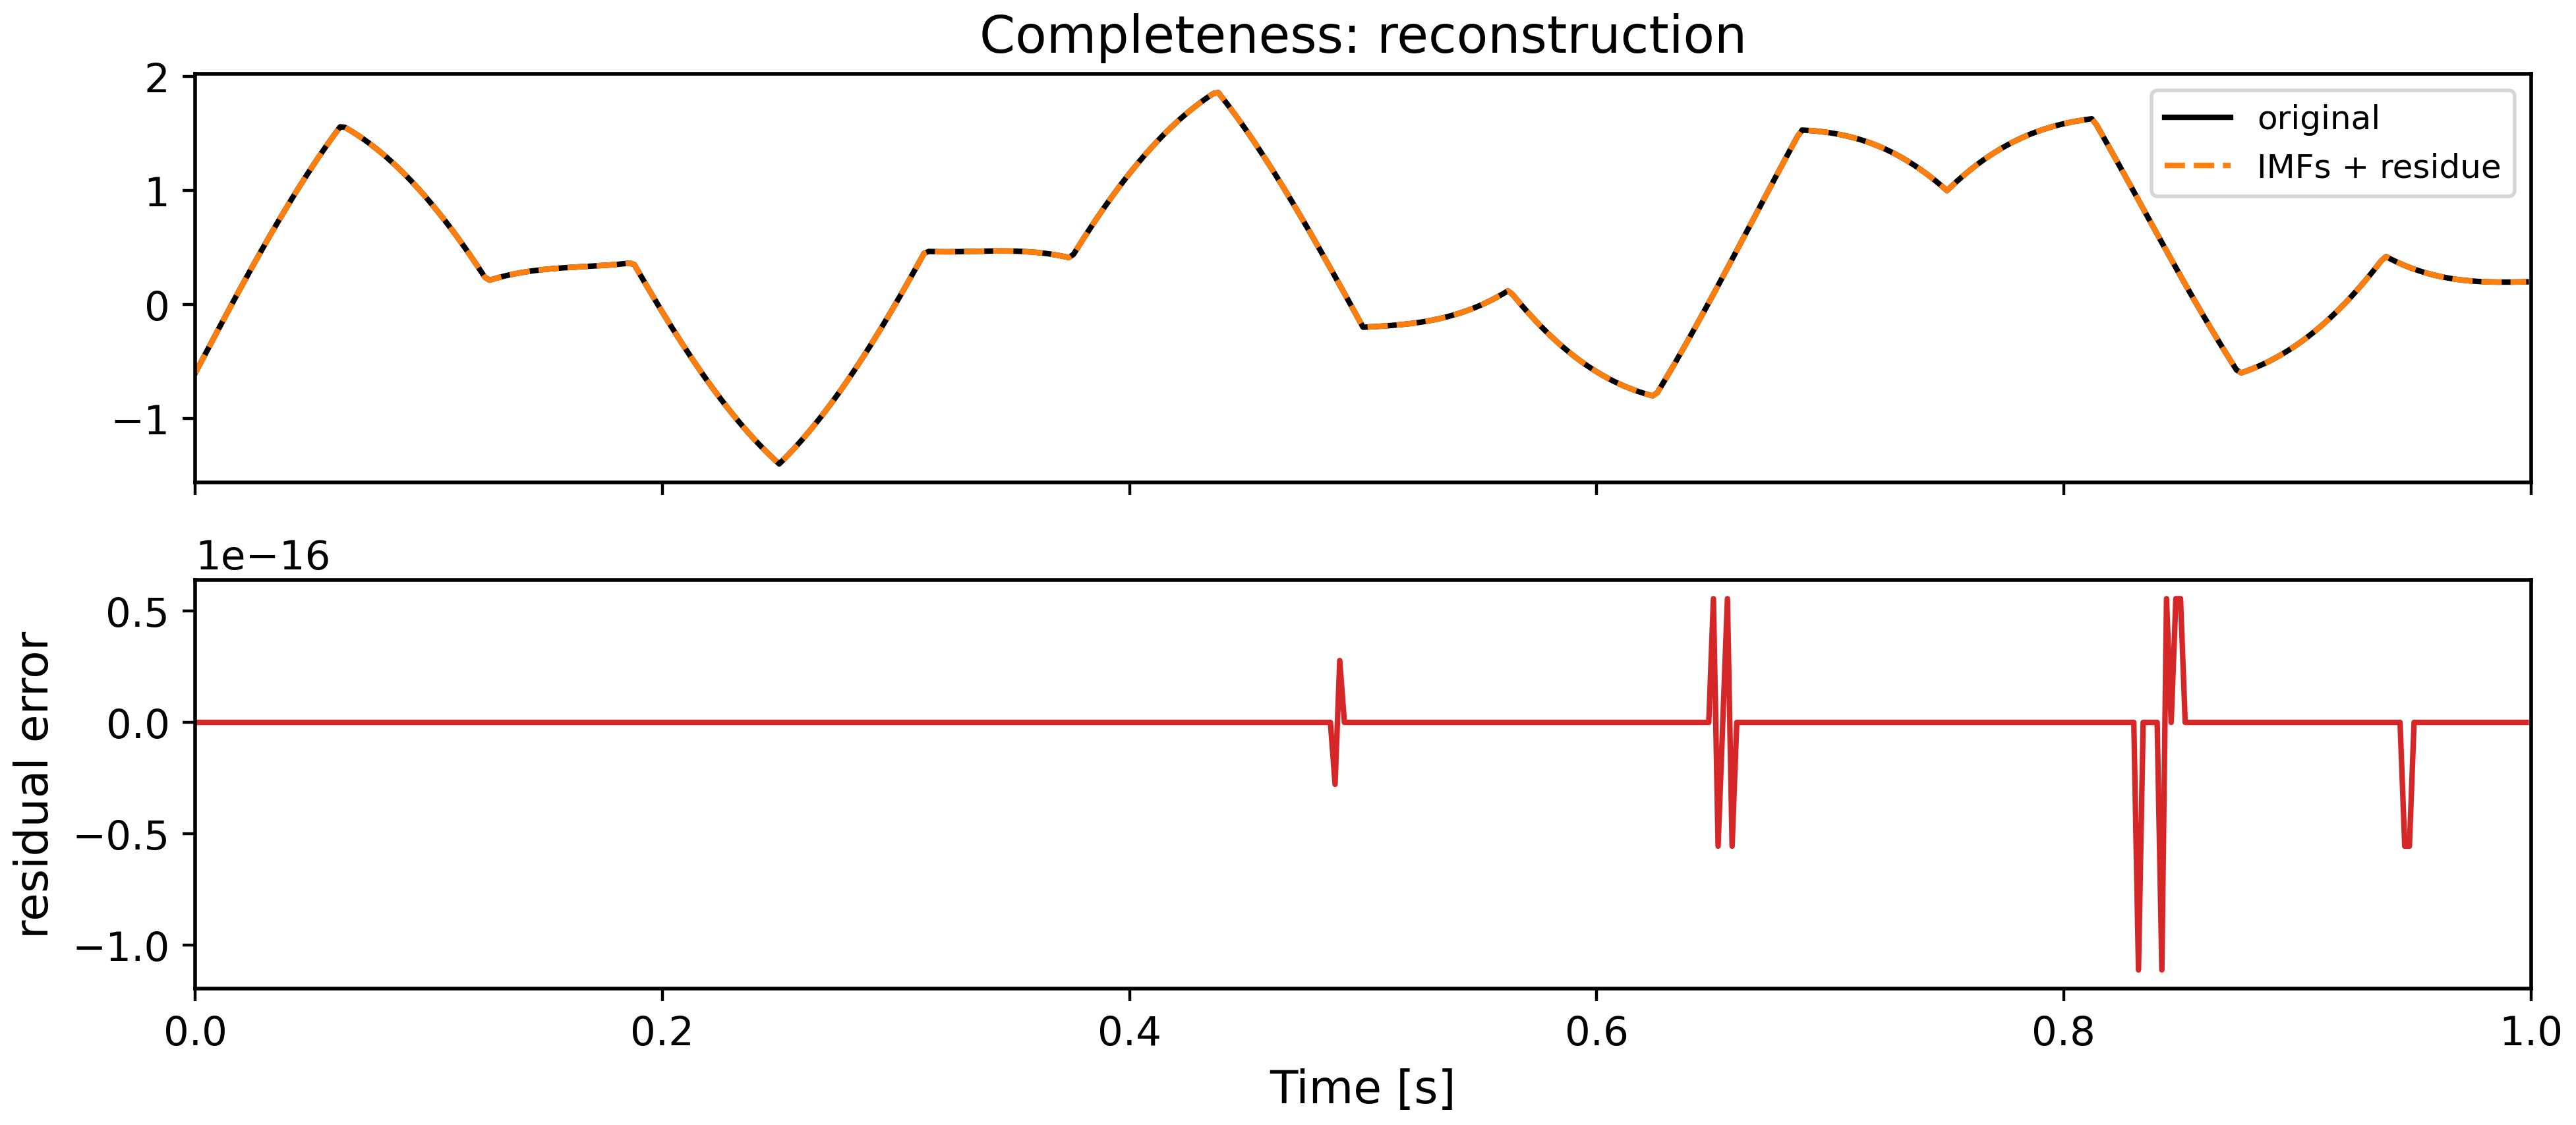

In [8]:
emd = EMD(spline_kind="cubic", extrema_detection="simple", max_imfs=4)
imfs = emd.fit_transform(x, time=t)
imfs_arr, residue = emd.get_imfs_and_residue()
print("IMFs shape (n_imfs, T):", imfs_arr.shape)
print("residue energy fraction:", np.sum(residue**2) / np.sum(x**2))

fig = plot_IMFs(x, imfs_arr, return_figure=True)
plt.show()

recon = imfs_arr.sum(axis=0) + residue
print("relative reconstruction error:", relative_error(x, recon))

fig, axs = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
axs[0].plot(t, x, "k", label="original")
axs[0].plot(t, recon, "C1--", label="IMFs + residue")
axs[0].legend(fontsize=9)
axs[0].set_title("Completeness: reconstruction")
axs[1].plot(t, x - recon, color="C3")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("residual error")
axs[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 10. Another example: PySDKit `test_emd` chirp + trend

$$
x(t)=\cos(22\pi t^2)+2t^2+\text{noise}
$$
is a classic non-stationary test used inside PySDKit.


IMFs shape: (6, 1000)
relative recon. error: 7.121931559202244e-17


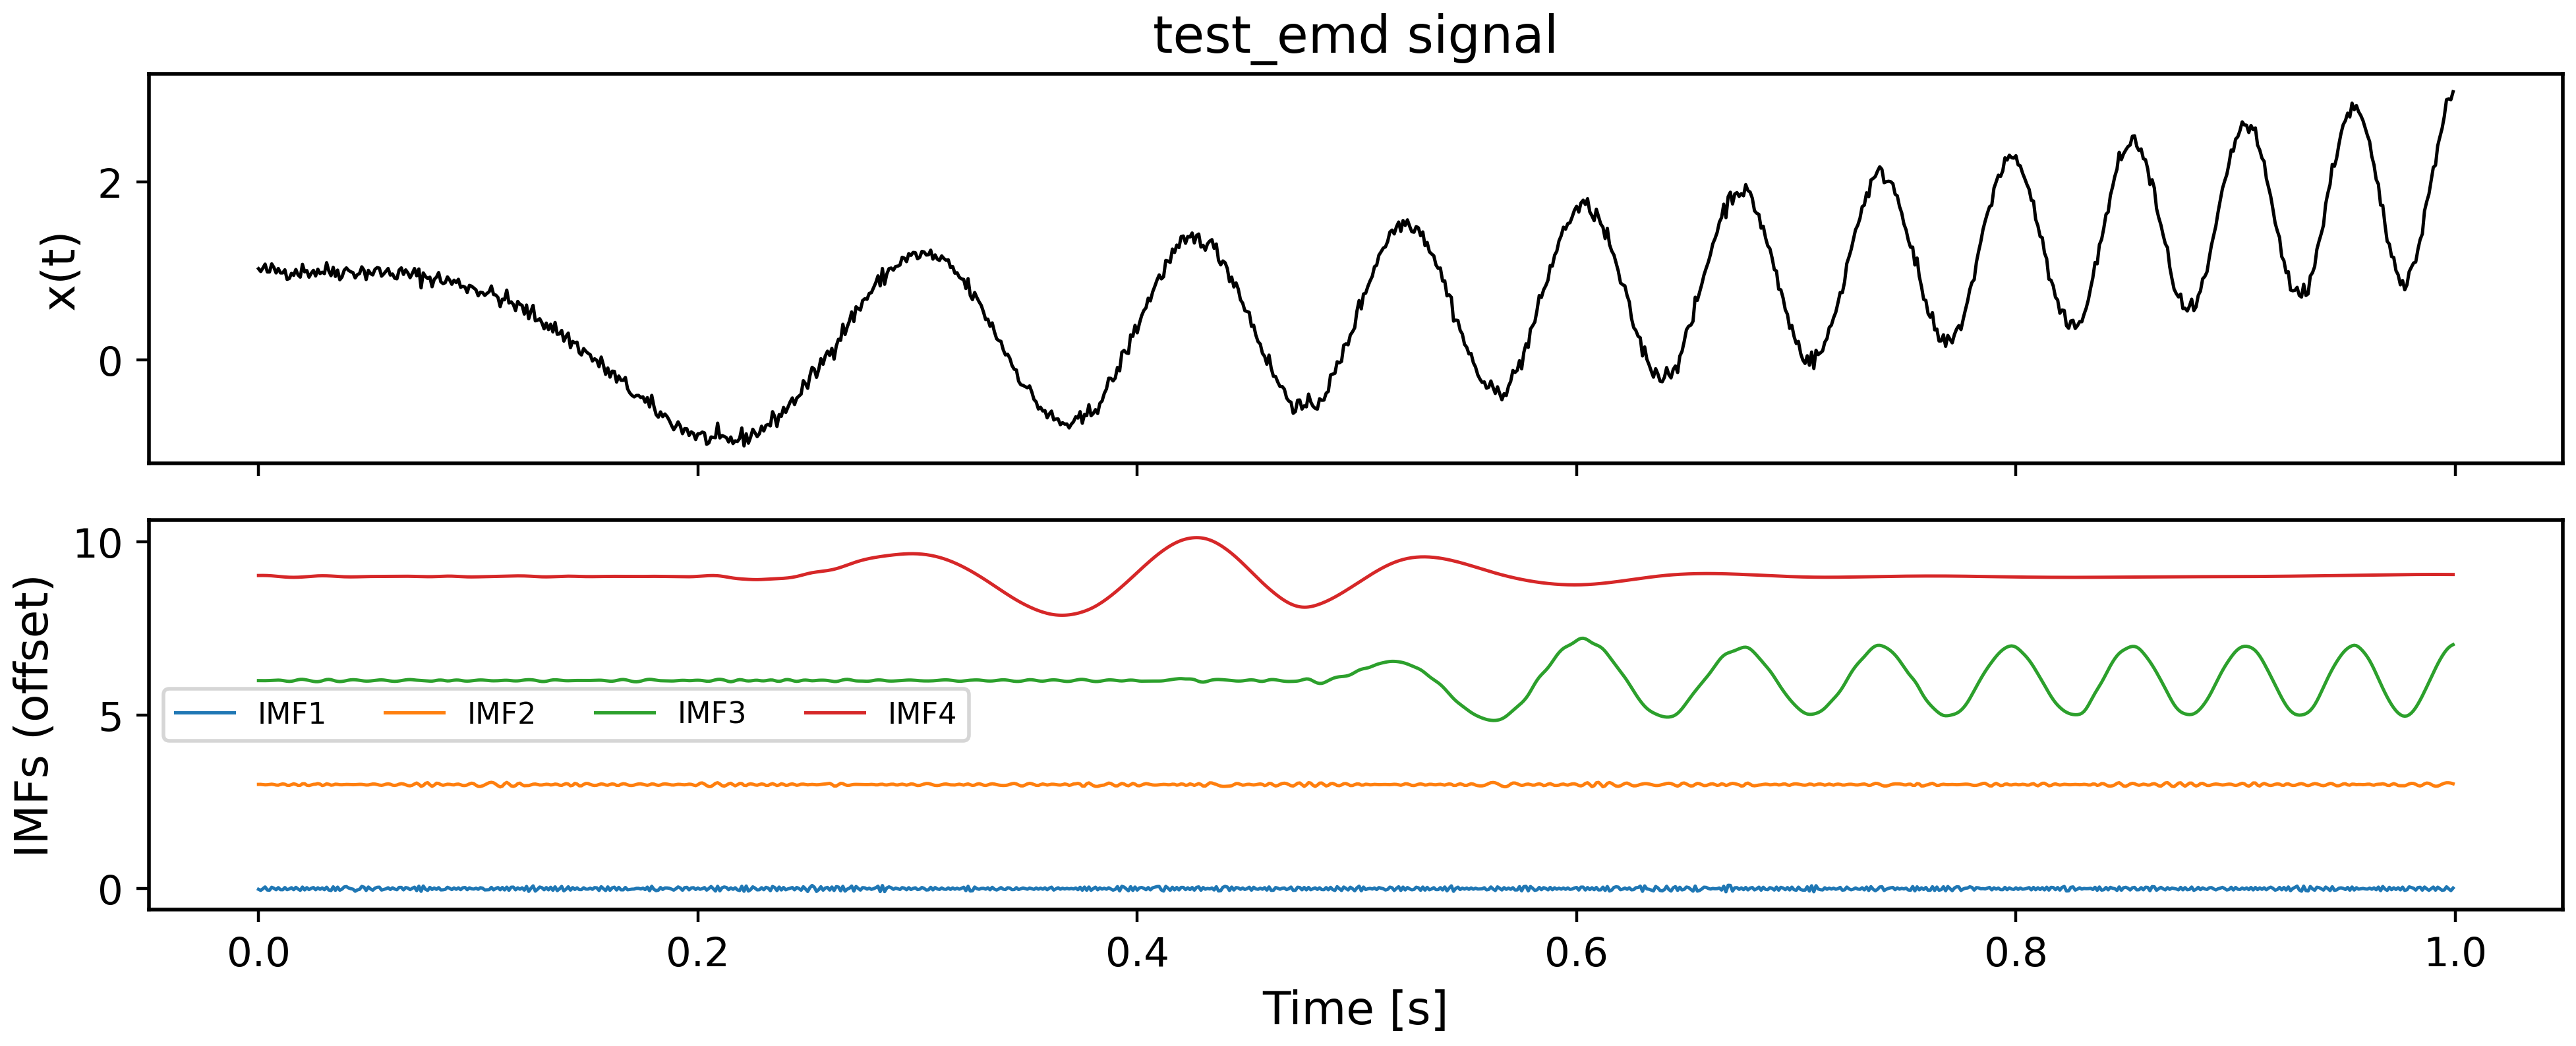

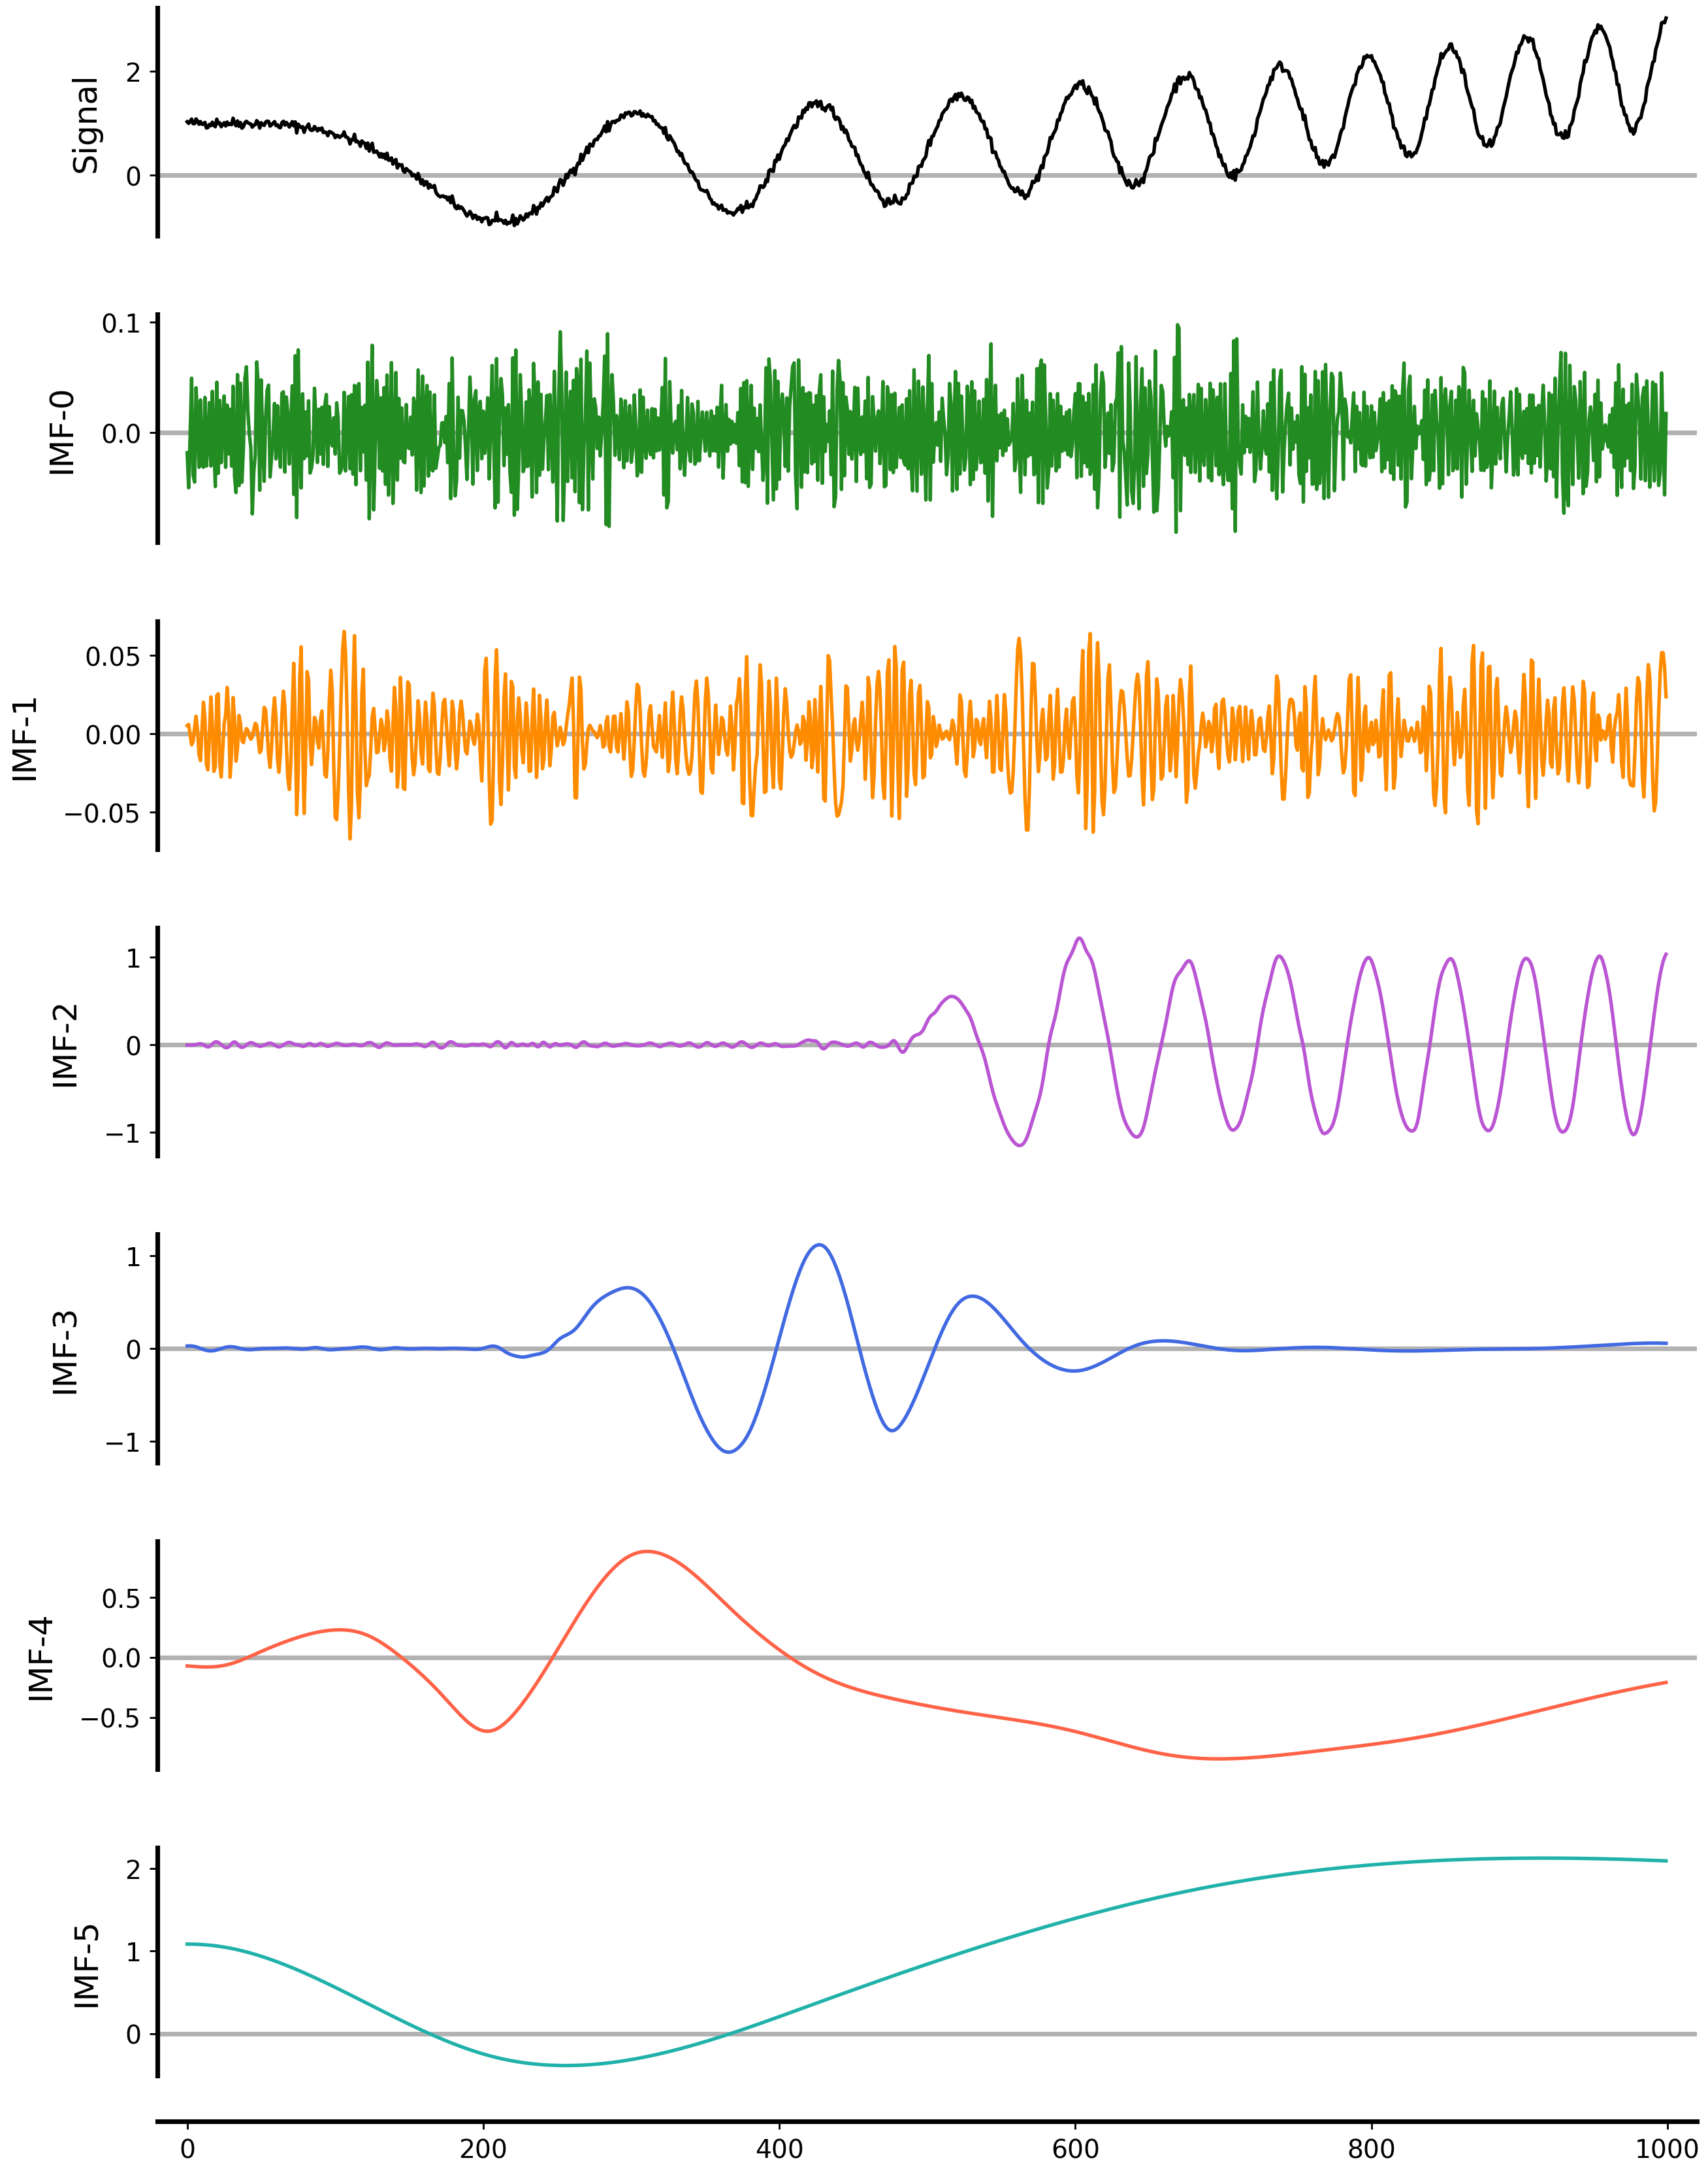

In [9]:
t2, x2 = test_emd(duration=1.0, sampling_rate=1000, noise_level=0.05)
emd2 = EMD(max_imfs=5)
imfs2 = emd2.fit_transform(x2, time=t2)
print("IMFs shape:", imfs2.shape)
print("relative recon. error:", relative_error(x2, imfs2.sum(0)))

fig, axs = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True)
axs[0].plot(t2, x2, "k", lw=0.9)
axs[0].set_title("test_emd signal")
axs[0].set_ylabel("x(t)")
for k in range(min(4, imfs2.shape[0])):
    axs[1].plot(t2, imfs2[k] + 3 * k, lw=0.9, label=f"IMF{k+1}")
axs[1].legend(fontsize=8, ncol=4)
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("IMFs (offset)")
plt.tight_layout()
plt.show()

fig = plot_IMFs(x2, imfs2, return_figure=True)
plt.show()

## 11. Summary

| Stage | Operation | Role |
|-------|-----------|------|
| A | Find maxima / minima | Local time-scale landmarks |
| B | Cubic envelopes $U,L$ | Local oscillation range |
| C | Mean $m=(U+L)/2$ | Low-frequency local trend |
| D | $h\leftarrow h-m$ | Isolate fast detail (sifting) |
| Repeat | Until IMF criteria | Zero-mean, balanced extrema |
| Outer loop | Residue $r\leftarrow r-\mathrm{IMF}$ | Extract next slower mode |

**Key takeaways**

1. EMD is **data-driven**: no preset frequencies or mother wavelet.  
2. Sifting is a local, iterative high-pass operation guided by envelopes.  
3. Completeness: $x=\sum\mathrm{IMFs}+r$.  
4. IMFs enable the **Hilbert–Huang Transform** (next notebook: `hht.ipynb`).

### One-liner

```python
from pysdkit import EMD
imfs = EMD(max_imfs=4).fit_transform(signal)
```
